In [31]:
import torch
from torch import nn # nn contails all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

# 1. Data preparatin and loading

In [32]:
weights = 0.7
bias = 0.3

# create data

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)

y = weights * X + bias

X[:10] , y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [33]:
len(X), len(y)

(50, 50)

## Spliting data into training and test sets (one of the most important concept in ML in general)

In [34]:
train_split = int(0.8 * len(X))
train_split

40

In [35]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test, = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

data visualization

In [36]:
def plot_predictions(train_data = X_train , train_labels= y_train,
                     test_data = X_test, test_labels= y_test,
                     predictions= None):
  plt.figure(figsize = (10,7))

  plt.scatter(train_data, train_labels, c = "b", s=4, label="Training data")

  plt.scatter(test_data, test_labels, c = "g", s= 4, label = "Testing data")

  if predictions is not None:

    plt.scatter(test_data, predictions, c = "r", s=4, label= "Predctions")

  plt.legend(prop={"size" : 14})

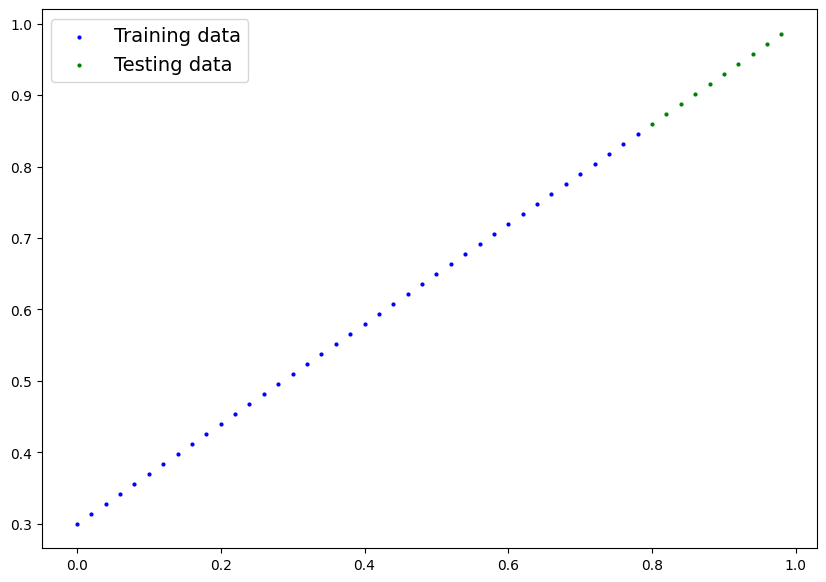

In [37]:
plot_predictions()

 #@ 2.building model

In [38]:
# create linear regression model class
from torch import nn

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1,
                                          requires_grad=True,
                                          dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [39]:
### checking the contents of PyTorch model


# creatre random seed
torch.manual_seed(42)

#Create an instance of the model ( this is a subclass of nn.Module)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([-0.6382], requires_grad=True)]

In [40]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([-0.6382]))])

In [41]:
weights, bias

(0.7, 0.3)

Making prediction using torch.inference_mode()


In [42]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [43]:
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.0677],
        [0.0853],
        [0.1030],
        [0.1206],
        [0.1382],
        [0.1559],
        [0.1735],
        [0.1912],
        [0.2088],
        [0.2265]])

In [44]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

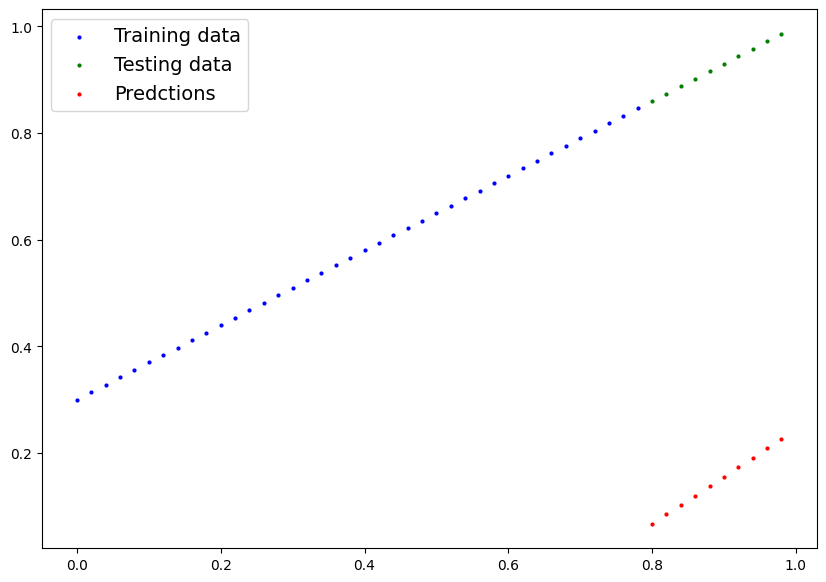

In [45]:
plot_predictions(predictions=y_preds)

to read about torch.inference_mode()

In [46]:
## 3. TRAIN MODEL

list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([-0.6382], requires_grad=True)]

In [47]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([-0.6382]))])

# setup loss function
# setup an optimizer
# building training loop

In [48]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.01)

In [155]:
epochs = 10

for epoch in range (epochs):
  model_0.train() #train mode

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred, y_train)
  print(f"Loss: {loss}")

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval() #trun off gradient tracking

  print(model_0.state_dict())


Loss: 0.0070777395740151405
OrderedDict({'weights': tensor([0.7044]), 'bias': tensor([0.2938])})
Loss: 0.004443249199539423
OrderedDict({'weights': tensor([0.7083]), 'bias': tensor([0.3038])})
Loss: 0.0070777395740151405
OrderedDict({'weights': tensor([0.7044]), 'bias': tensor([0.2938])})
Loss: 0.004443249199539423
OrderedDict({'weights': tensor([0.7083]), 'bias': tensor([0.3038])})
Loss: 0.0070777395740151405
OrderedDict({'weights': tensor([0.7044]), 'bias': tensor([0.2938])})
Loss: 0.004443249199539423
OrderedDict({'weights': tensor([0.7083]), 'bias': tensor([0.3038])})
Loss: 0.0070777395740151405
OrderedDict({'weights': tensor([0.7044]), 'bias': tensor([0.2938])})
Loss: 0.004443249199539423
OrderedDict({'weights': tensor([0.7083]), 'bias': tensor([0.3038])})
Loss: 0.0070777395740151405
OrderedDict({'weights': tensor([0.7044]), 'bias': tensor([0.2938])})
Loss: 0.004443249199539423
OrderedDict({'weights': tensor([0.7083]), 'bias': tensor([0.3038])})


In [157]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

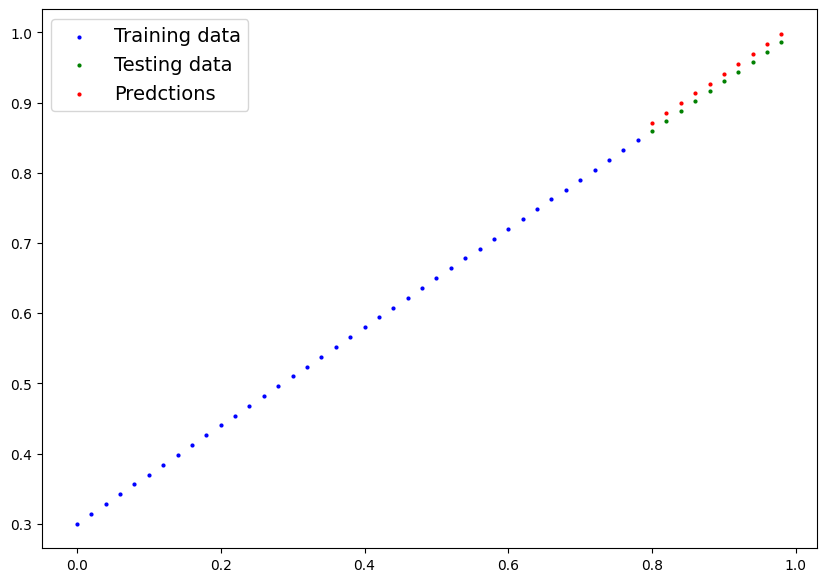

In [159]:
plot_predictions(predictions=y_preds_new)

In [50]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8862])), ('bias', tensor([-0.6282]))])